In [2]:
import MDAnalysis as mda

top = "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_1/run1/dna_initial.pdb"

sub_1 = [
    "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run2/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_3/run1/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_3/run2/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_4/run1/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_4/run2/dna_traj.dcd",
]

sub_2 = [
    "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_2/run1/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_2/run2/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_3/run1/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_3/run2/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_4/run1/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_4/run2/dna_traj.dcd",
]

for i in range(6):
    n1 = len(mda.Universe(top, sub_1[i]).trajectory)
    n2 = len(mda.Universe(top, sub_2[i]).trajectory)

    print(f"Replica {i+1}: {n1} + {n2} = {n1+n2} frames")

/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Replica 1: 6356 + 22044 = 28400 frames
Replica 2: 14221 + 21974 = 36195 frames
Replica 3: 4676 + 21993 = 26669 frames
Replica 4: 4685 + 22023 = 26708 frames
Replica 5: 22050 + 22032 = 44082 frames
Replica 6: 21920 + 980 = 22900 frames


Mean temperature: 297.77 K
Mean potential energy: -39239.67 kJ/mole
Mean kinetic energy: 101989.98 kJ/mole
Mean total energy: 62750.30 kJ/mole


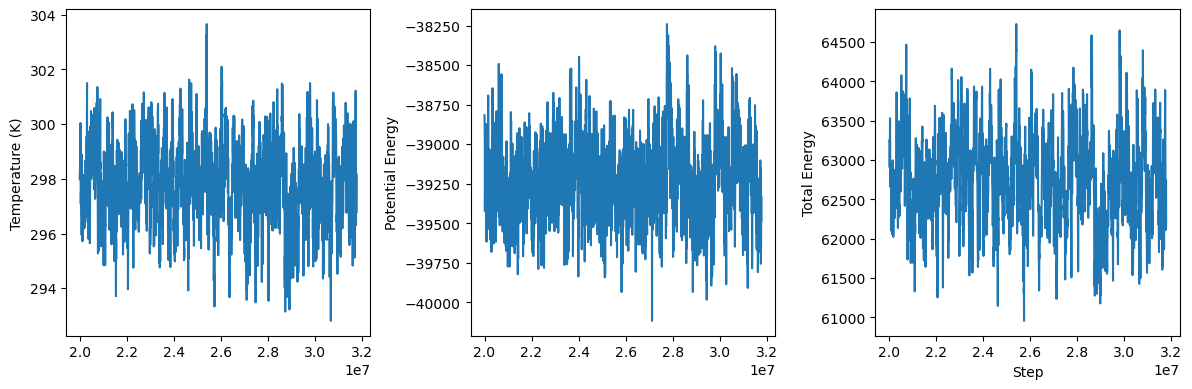

Mean temperature: 297.77 K
Mean potential energy: -39180.48 kJ/mole
Mean kinetic energy: 101989.92 kJ/mole
Mean total energy: 62809.44 kJ/mole


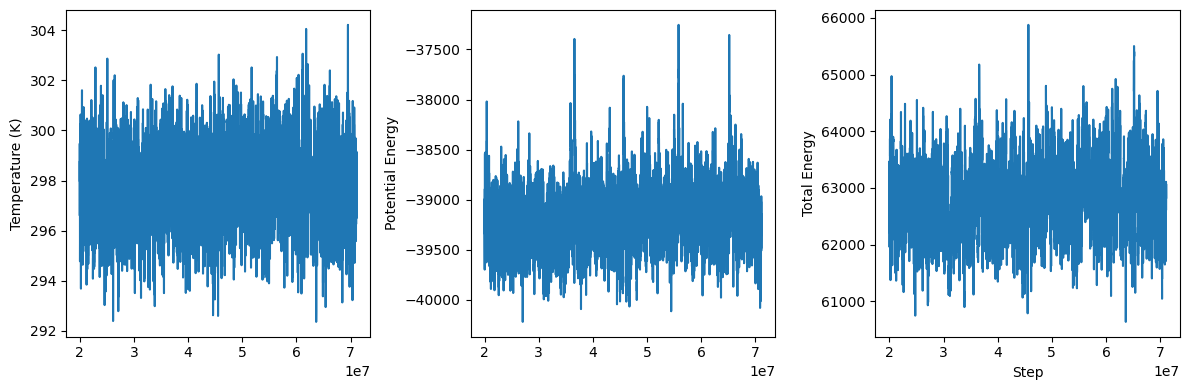

Mean temperature: 297.73 K
Mean potential energy: -39297.47 kJ/mole
Mean kinetic energy: 101974.33 kJ/mole
Mean total energy: 62676.85 kJ/mole


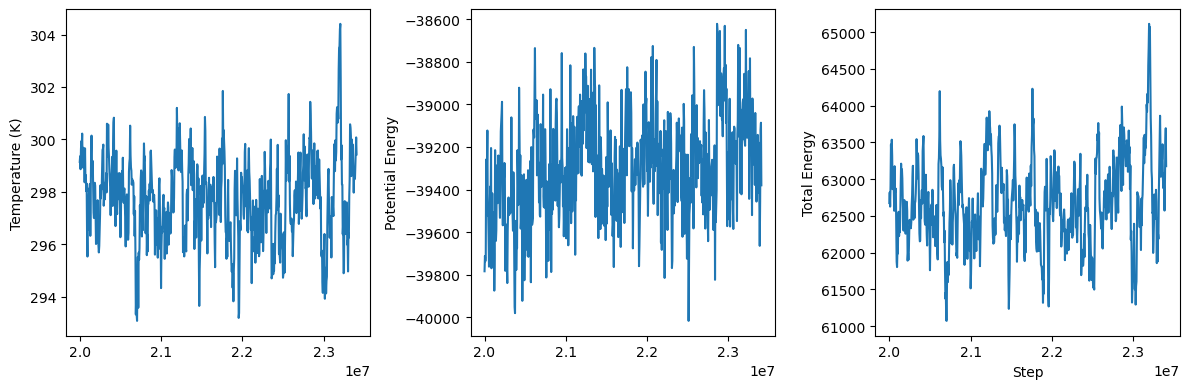

Mean temperature: 297.78 K
Mean potential energy: -39130.63 kJ/mole
Mean kinetic energy: 101993.71 kJ/mole
Mean total energy: 62863.08 kJ/mole


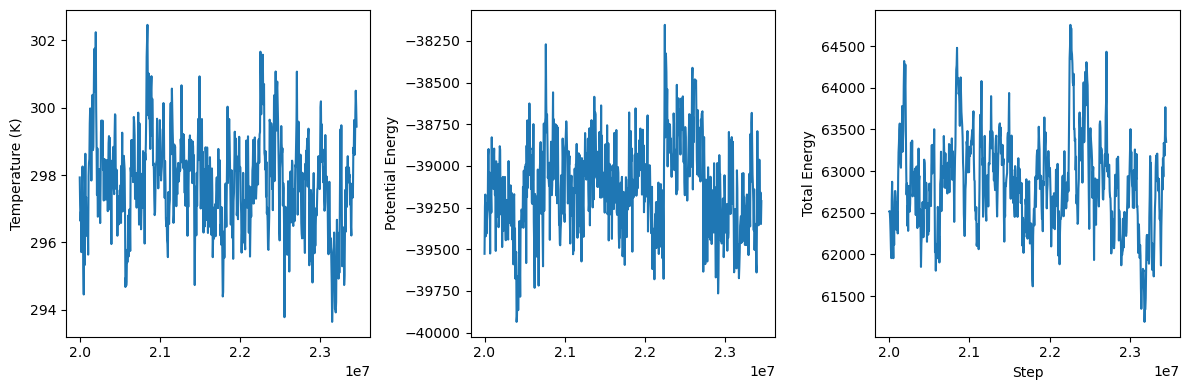

Mean temperature: 297.97 K
Mean potential energy: -39105.33 kJ/mole
Mean kinetic energy: 102056.74 kJ/mole
Mean total energy: 62951.40 kJ/mole


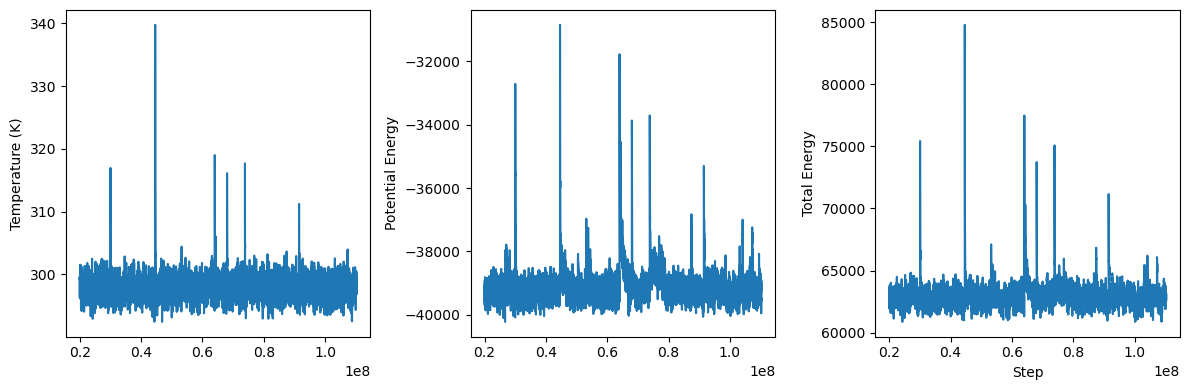

Mean temperature: 297.83 K
Mean potential energy: -39313.03 kJ/mole
Mean kinetic energy: 102010.81 kJ/mole
Mean total energy: 62697.78 kJ/mole


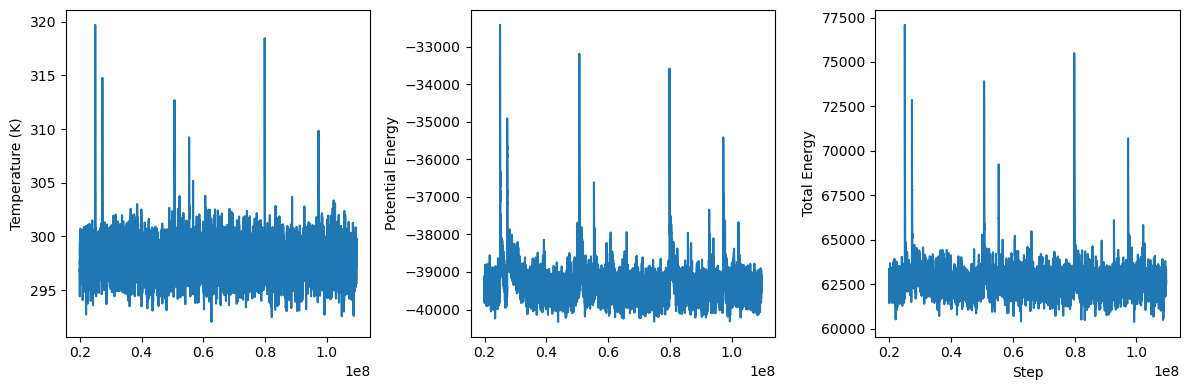

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

logfile = ["/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run2/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_3/run1/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_3/run2/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_4/run1/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_4/run2/dna_log.csv",]  # replace with your file

for file in logfile:
    df = pd.read_csv(file)
    # Remove equilibration
    df_prod = df[df["Step"] >= 20000000].copy()

    # Reset step number so production starts at 0
    df_prod["ProdStep"] = df_prod["Step"] - 20000000

    mean_temp = df_prod["Temperature (K)"].mean()
    print(f"Mean temperature: {mean_temp:.2f} K")
    mean_pot_energy = df_prod["Potential Energy (kJ/mole)"].mean()
    print(f"Mean potential energy: {mean_pot_energy:.2f} kJ/mole")
    mean_kin_energy = df_prod["Kinetic Energy (kJ/mole)"].mean()
    print(f"Mean kinetic energy: {mean_kin_energy:.2f} kJ/mole")
    mean_tot_energy = (df_prod["Potential Energy (kJ/mole)"] + df_prod["Kinetic Energy (kJ/mole)"]).mean()
    print(f"Mean total energy: {mean_tot_energy:.2f} kJ/mole")

    fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

    ax[0].plot(df_prod["#\"Step\""] if "#\"Step\"" in df.columns else df_prod["Step"],
            df_prod["Temperature (K)"])
    ax[0].set_ylabel("Temperature (K)")

    ax[1].plot(df_prod["Step"], df_prod["Potential Energy (kJ/mole)"])
    ax[1].set_ylabel("Potential Energy")

    ax[2].plot(df_prod["Step"],
            df_prod["Potential Energy (kJ/mole)"]
            + df_prod["Kinetic Energy (kJ/mole)"])
    ax[2].set_ylabel("Total Energy")
    ax[2].set_xlabel("Step")

    plt.tight_layout()
    plt.show()

Mean temperature: 297.87 K
Mean potential energy: -39144.44 kJ/mole
Mean kinetic energy: 102024.97 kJ/mole
Mean total energy: 62880.53 kJ/mole


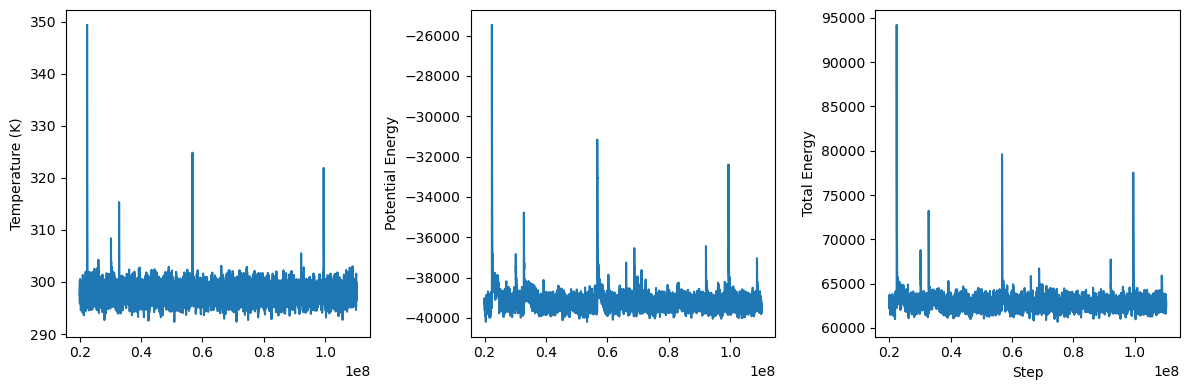

Mean temperature: 297.88 K
Mean potential energy: -39154.63 kJ/mole
Mean kinetic energy: 102026.82 kJ/mole
Mean total energy: 62872.19 kJ/mole


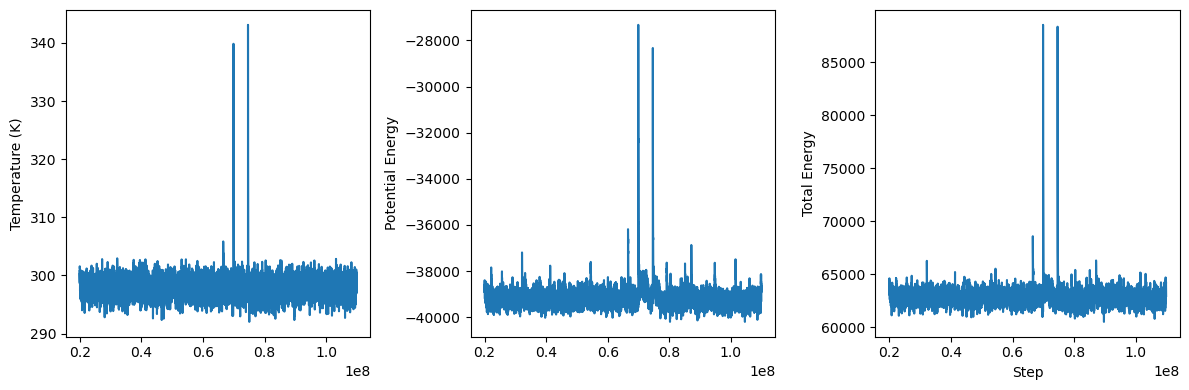

Mean temperature: 297.78 K
Mean potential energy: -39234.52 kJ/mole
Mean kinetic energy: 101993.32 kJ/mole
Mean total energy: 62758.80 kJ/mole


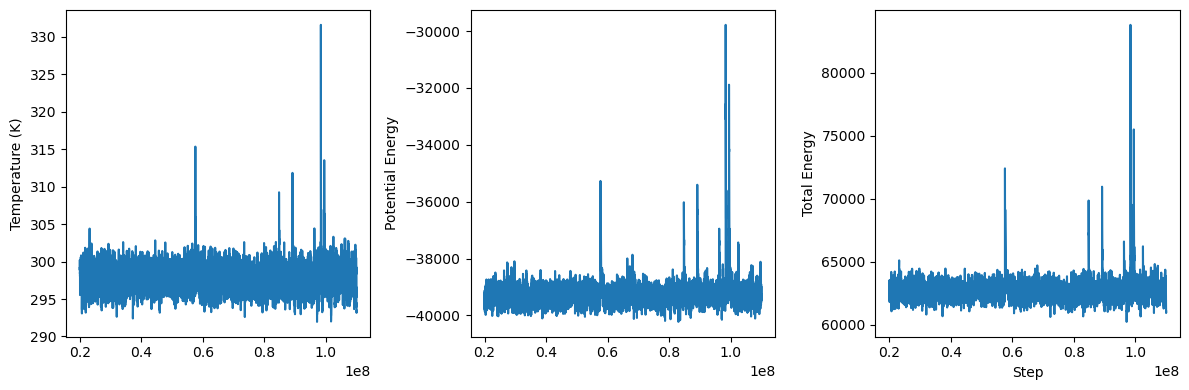

Mean temperature: 297.83 K
Mean potential energy: -39176.03 kJ/mole
Mean kinetic energy: 102008.61 kJ/mole
Mean total energy: 62832.59 kJ/mole


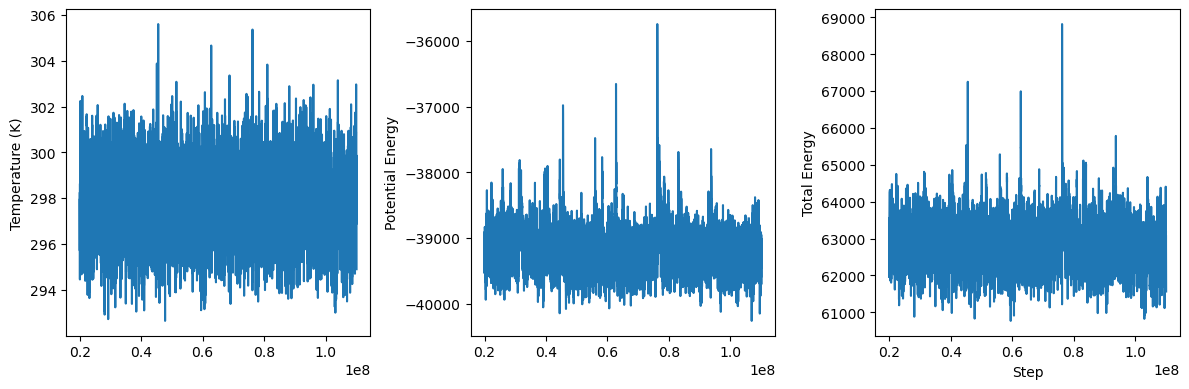

Mean temperature: 297.84 K
Mean potential energy: -39214.97 kJ/mole
Mean kinetic energy: 102014.05 kJ/mole
Mean total energy: 62799.08 kJ/mole


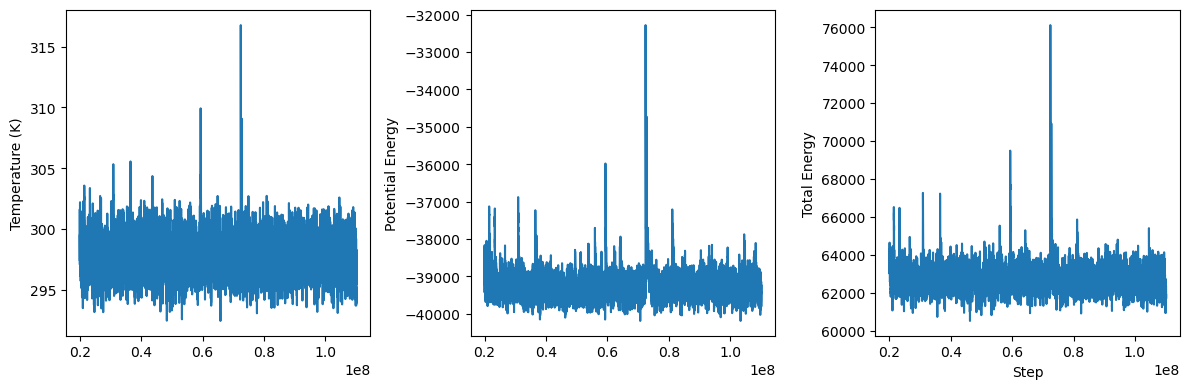

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

logfile = ["/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_2/run1/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_2/run2/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_3/run1/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_3/run2/dna_log.csv",
           "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_4/run1/dna_log.csv",
        #    "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_4/run2/dna_log.csv",
        ]  # replace with your file

for file in logfile:
    df = pd.read_csv(file)
    # Remove equilibration
    df_prod = df[df["Step"] >= 20000000].copy()

    # Reset step number so production starts at 0
    df_prod["ProdStep"] = df_prod["Step"] - 20000000

    mean_temp = df_prod["Temperature (K)"].mean()
    print(f"Mean temperature: {mean_temp:.2f} K")
    mean_pot_energy = df_prod["Potential Energy (kJ/mole)"].mean()
    print(f"Mean potential energy: {mean_pot_energy:.2f} kJ/mole")
    mean_kin_energy = df_prod["Kinetic Energy (kJ/mole)"].mean()
    print(f"Mean kinetic energy: {mean_kin_energy:.2f} kJ/mole")
    mean_tot_energy = (df_prod["Potential Energy (kJ/mole)"] + df_prod["Kinetic Energy (kJ/mole)"]).mean()
    print(f"Mean total energy: {mean_tot_energy:.2f} kJ/mole")

    fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

    ax[0].plot(df_prod["#\"Step\""] if "#\"Step\"" in df.columns else df_prod["Step"],
            df_prod["Temperature (K)"])
    ax[0].set_ylabel("Temperature (K)")

    ax[1].plot(df_prod["Step"], df_prod["Potential Energy (kJ/mole)"])
    ax[1].set_ylabel("Potential Energy")

    ax[2].plot(df_prod["Step"],
            df_prod["Potential Energy (kJ/mole)"]
            + df_prod["Kinetic Energy (kJ/mole)"])
    ax[2].set_ylabel("Total Energy")
    ax[2].set_xlabel("Step")

    plt.tight_layout()
    plt.show()

In [31]:
"""
build_nucleosome_cg.py
=======================
Converts an all-atom nucleosome structure (e.g. 2CV5) into a combined
coarse-grained (CG) structure:

    - Histone proteins  -> SOP model (Self-Organized Polymer), a single
                            bead per residue, placed at the CA position
                            (same convention as your existing histone
                            CA-extraction script).
    - DNA                -> TIS model (Three-Interaction-Site), three
                            beads per nucleotide -- Phosphate (P), Sugar
                            (S), Base (B) -- each placed at the center of
                            mass of its heavy-atom group, following
                            Chakraborty, Hori & Thirumalai (JCTC 2018).
                            (Same logic as your AA2TIS_dna.py.)

Both bead sets are written into ONE combined CG PDB file, using the
same fixed-width writer style as your existing scripts.

After building the CG structure, the script counts DNA-histone
contacts: a histone bead and a DNA bead are considered "in contact" if
the distance between them is <= contact_cutoff (Angstrom). This is a
simple CG bead-distance definition (not an all-atom overlap/shadow
map) -- appropriate once you're already working in bead space, but
worth remembering if you later compare to all-atom contact counts.

Config (input.json), all keys except aa_pdb/histone_chains/dna_chains
are optional:

    aa_pdb          : path to the all-atom PDB (e.g. "2CV5.pdb")
    cg_pdb          : output combined CG PDB path   (default "nucleosome_cg.pdb")
    histone_chains  : list of histone chain IDs      e.g. ["A","B","C","D","E","F","G","H"]
    dna_chains      : list of DNA chain IDs           e.g. ["I","J"]
    contact_cutoff  : distance cutoff in Angstrom for a bead-bead contact (default 10.0)
    contact_report  : path for the contact summary   (default "dna_histone_contacts.txt")
"""

import json
from collections import defaultdict

# ---------------------------------------------------------------
# Shared masses / element guesser (used for DNA center-of-mass beads)
# ---------------------------------------------------------------
MASS = {"C": 12.011, "N": 14.007, "O": 15.999, "P": 30.974}


def element_of(atom_name):
    """Guess element from a PDB atom name (heavy atoms only)."""
    name = atom_name.strip()
    if name.startswith("P"):
        return "P"
    for ch in name:
        if ch.isalpha():
            return ch
    return "C"


PHOSPHATE_ATOMS = {"P", "OP1", "OP2", "O1P", "O2P", "O5'"}
SUGAR_ATOMS = {"C1'", "C2'", "C3'", "C4'", "C5'", "O4'", "O3'", "O2'"}
# everything else on the nucleotide is treated as base

BASE_3LETTER = {"A": "DA", "T": "DT", "G": "DG", "C": "DC"}
RESNAME_TO_LETTER = {
    "DA": "A", "DT": "T", "DG": "G", "DC": "C",
    "A": "A", "T": "T", "G": "G", "C": "C",
    "ADE": "A", "THY": "T", "GUA": "G", "CYT": "C",
}


# =================================================================
# 1. Histones -> SOP (single-bead, CA-based) beads
# =================================================================
def build_sop_beads(aa_pdb_file, histone_chains):
    """One bead per protein residue, placed at the CA coordinate."""
    beads = []
    chain_counts = {}
    with open(aa_pdb_file) as f:
        for line in f:
            if line[:6].strip() != "ATOM":
                continue
            atom_name = line[12:16].strip()
            chain = line[21]
            if chain not in histone_chains or atom_name != "CA":
                continue
            resname = line[17:20].strip()
            resid = int(line[22:26])
            x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
            chain_counts[chain] = chain_counts.get(chain, 0) + 1
            beads.append({
                "chain": chain, "resid": resid, "resname": resname,
                "bead": "BB", "x": x, "y": y, "z": z, "kind": "protein",
            })
    return beads, chain_counts


# =================================================================
# 2. DNA -> TIS (three-bead: P, S, B) beads
# =================================================================
def parse_aa_dna(aa_pdb_file, dna_chains):
    residues = defaultdict(dict)
    with open(aa_pdb_file) as f:
        for line in f:
            record = line[:6].strip()
            if record not in ("ATOM", "HETATM"):
                continue
            chain = line[21]
            if chain not in dna_chains:
                continue
            resname = line[17:20].strip()
            if resname not in RESNAME_TO_LETTER:
                continue
            resid = int(line[22:26])
            atom_name = line[12:16].strip()
            x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
            if resid not in residues[chain]:
                residues[chain][resid] = {"resname": RESNAME_TO_LETTER[resname], "atoms": {}}
            residues[chain][resid]["atoms"][atom_name] = (x, y, z)
    return residues


def center_of_mass(atom_coords):
    sx = sy = sz = 0.0
    mtot = 0.0
    for name, (x, y, z) in atom_coords.items():
        m = MASS.get(element_of(name), 12.0)
        sx += m * x; sy += m * y; sz += m * z
        mtot += m
    if mtot == 0.0:
        raise ValueError("Empty atom group; cannot compute center of mass.")
    return (sx / mtot, sy / mtot, sz / mtot)


def build_tis_beads(residues, chain_order):
    all_beads = []
    sequences = {}
    for ch in chain_order:
        if ch not in residues:
            continue
        resids_sorted = sorted(residues[ch].keys())
        seq_letters = []
        for resid in resids_sorted:
            res = residues[ch][resid]
            base_letter = res["resname"]
            seq_letters.append(base_letter)
            atoms = res["atoms"]

            phosphate_atoms = {n: c for n, c in atoms.items() if n in PHOSPHATE_ATOMS}
            sugar_atoms = {n: c for n, c in atoms.items() if n in SUGAR_ATOMS}
            base_atoms = {n: c for n, c in atoms.items()
                          if n not in PHOSPHATE_ATOMS and n not in SUGAR_ATOMS}

            # 5'-terminal residue of a chain usually has no phosphate group
            if len(phosphate_atoms) >= 2:
                p_com = center_of_mass(phosphate_atoms)
                all_beads.append({
                    "chain": ch, "resid": resid, "bead": "P",
                    "resname": BASE_3LETTER[base_letter], "base": base_letter,
                    "x": p_com[0], "y": p_com[1], "z": p_com[2], "kind": "dna",
                })

            if len(sugar_atoms) < 3:
                raise ValueError(
                    f"Chain {ch} resid {resid}: too few sugar atoms found "
                    f"({list(sugar_atoms.keys())}); check atom naming."
                )
            s_com = center_of_mass(sugar_atoms)
            all_beads.append({
                "chain": ch, "resid": resid, "bead": "S",
                "resname": BASE_3LETTER[base_letter], "base": base_letter,
                "x": s_com[0], "y": s_com[1], "z": s_com[2], "kind": "dna",
            })

            if len(base_atoms) < 3:
                raise ValueError(
                    f"Chain {ch} resid {resid}: too few base atoms found "
                    f"({list(base_atoms.keys())}); check atom naming."
                )
            b_com = center_of_mass(base_atoms)
            all_beads.append({
                "chain": ch, "resid": resid, "bead": "B",
                "resname": BASE_3LETTER[base_letter], "base": base_letter,
                "x": b_com[0], "y": b_com[1], "z": b_com[2], "kind": "dna",
            })

        sequences[ch] = "".join(seq_letters)
    return all_beads, sequences


# =================================================================
# 3. Writer -- one fixed-width PDB format shared by both bead types
# =================================================================
def write_cg_pdb(beads, outfile):
    with open(outfile, "w") as f:
        for i, b in enumerate(beads, start=1):
            f.write(
                "{:<6s}{:5d} {:^4s} {:>3s} {:1s}{:4d}    "
                "{:8.3f}{:8.3f}{:8.3f}  1.00  0.00\n".format(
                    "ATOM", i, b["bead"], b["resname"], b["chain"],
                    b["resid"], b["x"], b["y"], b["z"],
                )
            )
        f.write("END\n")


# =================================================================
# 4. DNA-histone contact counting
# =================================================================
def count_dna_histone_contacts(protein_beads, dna_beads, cutoff):
    """
    Counts a contact between every histone bead / DNA bead pair whose
    distance is <= cutoff (Angstrom). Returns:
      - total_pairs        : total bead-bead contact pairs
      - unique_res_pairs    : set of unique (histone chain,resid,DNA chain,resid)
      - per_chain           : contacts broken down by histone chain
    """
    cutoff2 = cutoff * cutoff
    total_pairs = 0
    unique_res_pairs = set()
    per_chain = defaultdict(int)

    for hb in protein_beads:
        hx, hy, hz = hb["x"], hb["y"], hb["z"]
        for db in dna_beads:
            dx = hx - db["x"]; dy = hy - db["y"]; dz = hz - db["z"]
            if dx * dx + dy * dy + dz * dz <= cutoff2:
                total_pairs += 1
                per_chain[hb["chain"]] += 1
                unique_res_pairs.add((hb["chain"], hb["resid"], db["chain"], db["resid"]))

    return total_pairs, unique_res_pairs, per_chain


# =================================================================
# main
# =================================================================
def main():
    config = json.load(open("input.json"))
    aa_pdb = config["aa_pdb"]
    cg_pdb = config.get("cg_pdb", "nucleosome_cg.pdb")
    histone_chains = config["histone_chains"]
    dna_chains = config["dna_chains"]
    cutoff = float(config.get("contact_cutoff", 10.0))
    report_out = config.get("contact_report", "dna_histone_contacts.txt")

    print(f"Reading all-atom structure from {aa_pdb} ...")

    protein_beads, chain_counts = build_sop_beads(aa_pdb, histone_chains)
    print(f"  SOP (histone) beads: {len(protein_beads)} across chains {sorted(chain_counts)}")

    residues = parse_aa_dna(aa_pdb, dna_chains)
    dna_beads, sequences = build_tis_beads(residues, dna_chains)
    n_p = sum(1 for b in dna_beads if b["bead"] == "P")
    n_s = sum(1 for b in dna_beads if b["bead"] == "S")
    n_b = sum(1 for b in dna_beads if b["bead"] == "B")
    print(f"  TIS (DNA) beads: {len(dna_beads)}  (P={n_p}, S={n_s}, B={n_b})")

    all_beads = protein_beads + dna_beads
    write_cg_pdb(all_beads, cg_pdb)
    print(f"\nSaved combined CG PDB ({len(all_beads)} beads) to: {cg_pdb}")

    total_pairs, unique_res_pairs, per_chain = count_dna_histone_contacts(
        protein_beads, dna_beads, cutoff
    )

    with open(report_out, "w") as f:
        f.write(f"DNA-histone CG contact analysis (cutoff = {cutoff} A)\n")
        f.write(f"Total bead-bead contact pairs: {total_pairs}\n")
        f.write(f"Unique (histone residue - DNA nucleotide) contact pairs: {len(unique_res_pairs)}\n\n")
        f.write("Contacts per histone chain:\n")
        for ch in sorted(per_chain):
            f.write(f"  Chain {ch}: {per_chain[ch]} bead-bead contacts\n")

    print(f"\n--- DNA-Histone contacts (cutoff = {cutoff} A) ---")
    print(f"Total bead-bead contact pairs  : {total_pairs}")
    print(f"Unique residue-nucleotide pairs: {len(unique_res_pairs)}")
    print("Per-chain breakdown:")
    for ch in sorted(per_chain):
        print(f"  {ch}: {per_chain[ch]}")
    print(f"\nSaved contact report to: {report_out}")


if __name__ == "__main__":
    main()

Reading all-atom structure from 2CV5.pdb ...
  SOP (histone) beads: 761 across chains ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
  TIS (DNA) beads: 874  (P=290, S=292, B=292)

Saved combined CG PDB (1635 beads) to: histone_cg.pdb

--- DNA-Histone contacts (cutoff = 10.0 A) ---
Total bead-bead contact pairs  : 1296
Unique residue-nucleotide pairs: 879
Per-chain breakdown:
  A: 236
  B: 105
  C: 177
  D: 148
  E: 247
  F: 115
  G: 136
  H: 132

Saved contact report to: dna_histone_contacts.txt


Histone beads: 952
DNA beads: 874
Using trajectory frame 28329 (time=219740.0006551341 ps) as the wound-state reference.
Native (wound-state) contacts = 2211
No periodic box detected -- computing distances without PBC.
Time reset detected at frame 6356


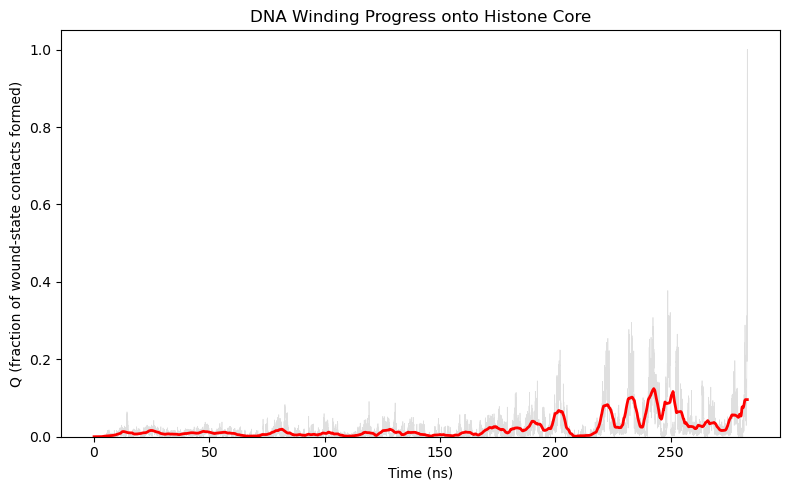


Final Q (last frame): 1.000
Max Q reached: 1.000


In [34]:
"""
dna_winding_Q.py
================
Tracks how the DNA-histone contact fraction (Q) evolves as the DNA
winds onto the histone core, starting from an unwound configuration.

Native ("wound-state") contacts are NOT taken from frame 0 -- frame 0
is your unwound start, so that would make Q measure "fraction of the
(mostly nonexistent) starting contacts retained," which doesn't track
winding at all.

REFERENCE_MODE controls where the wound-state reference comes from:

    "external_pdb"      : an independently built wound structure
                           (e.g. a CG PDB built from an all-atom
                           nucleosome that INCLUDES the histone tails --
                           bare crystal structures like 2CV5 usually
                           lack tail density, so a reference built from
                           them will NOT bead-match a simulation
                           topology that includes tails).
    "trajectory_frame"  : a frame of THIS trajectory/topology, so the
                           bead count/order is guaranteed to match.
                           Only trustworthy if you're confident that
                           frame is actually in the wound state.
"""

import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis.distances import distance_array
from scipy.ndimage import uniform_filter1d

# --------------------------------------------------
# INPUT
# --------------------------------------------------

topology = "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_initial.pdb"

trajs = [
    "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_traj.dcd",
    "/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_2/run2/dna_traj.dcd",
]

# "external_pdb"  -> set REFERENCE_PDB to a bead-matching wound structure
# "trajectory_frame" -> set REFERENCE_FRAME (e.g. -1 for last frame)
REFERENCE_MODE = "trajectory_frame"
REFERENCE_PDB = "nucleosome_cg.pdb"   # only used if REFERENCE_MODE == "external_pdb"
REFERENCE_FRAME = -1                  # only used if REFERENCE_MODE == "trajectory_frame"

cutoff_nm = 1.0
cutoff_A = cutoff_nm * 10.0

SELECTION_HISTONE = "(segid A B C D E F G H) and name BB"
SELECTION_DNA = "(segid I J) and (name P S B)"

SMOOTH_WINDOW = 500  # frames

# --------------------------------------------------
# LOAD SIMULATION TRAJECTORY
# --------------------------------------------------

u = mda.Universe(topology, trajs)

histone = u.select_atoms(SELECTION_HISTONE)
dna = u.select_atoms(SELECTION_DNA)

print("Histone beads:", len(histone))
print("DNA beads:", len(dna))

if len(histone) == 0 or len(dna) == 0:
    raise ValueError(
        "Selection returned 0 atoms -- check that 'segid' matches your "
        "topology (some readers store chain IDs under 'chainID' instead "
        "of 'segid'; try u.select_atoms(\"chainID A B ...\") if this fails)."
    )

# --------------------------------------------------
# REFERENCE (WOUND) CONTACTS
# --------------------------------------------------

if REFERENCE_MODE == "external_pdb":
    ref_u = mda.Universe(REFERENCE_PDB)
    ref_histone = ref_u.select_atoms(SELECTION_HISTONE)
    ref_dna = ref_u.select_atoms(SELECTION_DNA)

    if len(ref_histone) != len(histone) or len(ref_dna) != len(dna):
        raise ValueError(
            f"Reference bead counts (histone={len(ref_histone)}, dna={len(ref_dna)}) "
            f"don't match the trajectory (histone={len(histone)}, dna={len(dna)}). "
            "The reference must be built from a structure with the SAME "
            "residues/tails as your simulation topology -- a bare crystal "
            "structure missing histone tails will not match a simulation "
            "topology that includes them. Either regenerate the reference "
            "from the same all-atom source used to build your sim topology, "
            "or switch REFERENCE_MODE to 'trajectory_frame'."
        )

    ref_histone_pos = ref_histone.positions
    ref_dna_pos = ref_dna.positions

elif REFERENCE_MODE == "trajectory_frame":
    u.trajectory[REFERENCE_FRAME]
    ref_histone_pos = histone.positions.copy()
    ref_dna_pos = dna.positions.copy()
    print(f"Using trajectory frame {u.trajectory.frame} (time={u.trajectory.ts.time} ps) as the wound-state reference.")

else:
    raise ValueError(f"Unknown REFERENCE_MODE: {REFERENCE_MODE!r}")

ref_dist = distance_array(ref_histone_pos, ref_dna_pos)  # single static structure, no PBC
native_contacts = ref_dist < cutoff_A
N_native = native_contacts.sum()

print("Native (wound-state) contacts =", N_native)

if N_native == 0:
    raise ValueError(
        f"No contacts found in the reference structure at cutoff={cutoff_A} A. "
        "Check the reference (or reference frame) and cutoff before proceeding."
    )

# --------------------------------------------------
# DOES THE TRAJECTORY HAVE A VALID PERIODIC BOX?
# --------------------------------------------------

has_box = u.dimensions is not None and np.all(u.dimensions[:3] > 0)
if not has_box:
    print("No periodic box detected -- computing distances without PBC.")

# --------------------------------------------------
# ANALYSIS
# --------------------------------------------------

Q = []
n_contacts = []
times = []

time_offset = 0.0
previous_time = None

for ts in u.trajectory:
    current_time = ts.time

    # detect restart between concatenated runs (time counter resets to 0)
    if previous_time is not None and current_time < previous_time:
        time_offset += previous_time
        print(f"Time reset detected at frame {ts.frame}")

    corrected_time = current_time + time_offset
    times.append(corrected_time)

    dist = distance_array(
        histone.positions,
        dna.positions,
        box=u.dimensions if has_box else None,
    )

    current_contacts = dist < cutoff_A
    retained = np.logical_and(native_contacts, current_contacts).sum()

    Q.append(retained / N_native)
    n_contacts.append(current_contacts.sum())

    previous_time = current_time

Q = np.array(Q)
n_contacts = np.array(n_contacts)
times = np.array(times)

# --------------------------------------------------
# SMOOTHING
# --------------------------------------------------

smooth_window = min(SMOOTH_WINDOW, max(1, len(Q) // 2))
Q_smooth = uniform_filter1d(Q, size=smooth_window)

# --------------------------------------------------
# SAVE
# --------------------------------------------------

np.savetxt(
    "histone_DNA_Q.dat",
    np.column_stack((times, Q, n_contacts)),
    header="time_ps Q n_contacts",
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(times / 1000, Q, alpha=0.25, linewidth=0.5, color="grey")
plt.plot(times / 1000, Q_smooth, color="red", linewidth=2)

plt.xlabel("Time (ns)")
plt.ylabel("Q (fraction of wound-state contacts formed)")
plt.title("DNA Winding Progress onto Histone Core")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.savefig("histone_DNA_Q.png", dpi=300)
plt.show()

print(f"\nFinal Q (last frame): {Q[-1]:.3f}")
print(f"Max Q reached: {Q.max():.3f}")

Histone beads: 952
DNA beads: 874
DNA beads bound in final frame = 430
Time reset detected (frame 6356); adding offset 63560.0 ps


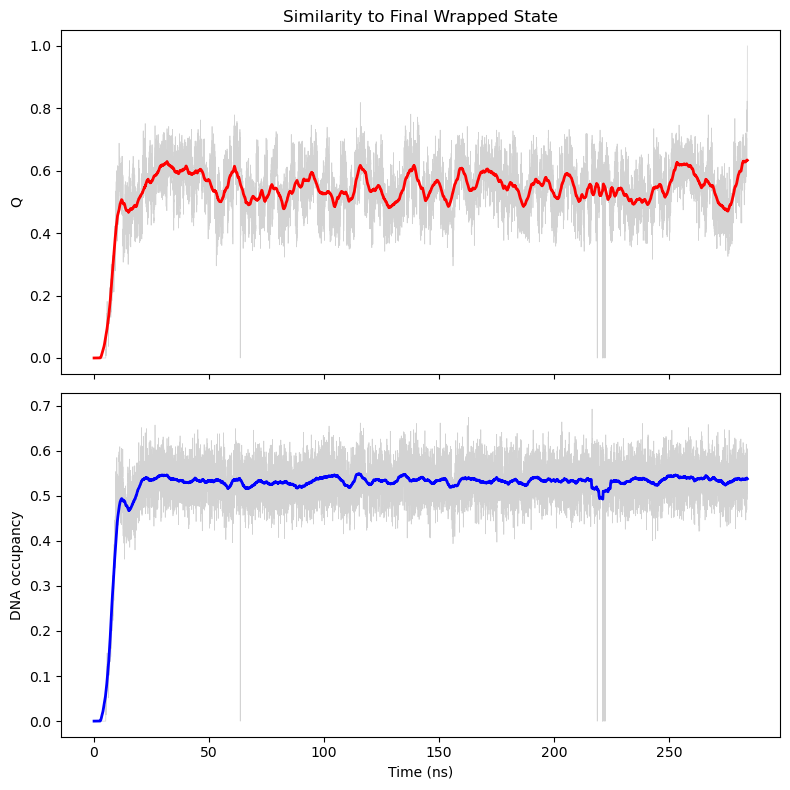

In [36]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis.distances import distance_array
from scipy.ndimage import uniform_filter1d

# --------------------------------------------------
# INPUT
# --------------------------------------------------

topology = "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_initial.pdb"

trajs = [
"/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_traj.dcd",
"/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_2/run1/dna_traj.dcd",
]

cutoff_nm = 1.0
cutoff_A = cutoff_nm * 10.0

smooth_window = 500

# --------------------------------------------------
# LOAD
# --------------------------------------------------

u = mda.Universe(topology, trajs)

histone = u.select_atoms(
    "(segid A B C D E F G H) and name BB"
)

dna = u.select_atoms(
    "(segid I J) and (name P S B)"
)

print("Histone beads:", len(histone))
print("DNA beads:", len(dna))

# --------------------------------------------------
# REFERENCE = LAST FRAME
# --------------------------------------------------

u.trajectory[-1]

ref_dist = distance_array(
    dna.positions,
    histone.positions,
    box=u.dimensions
)

ref_min_dist = ref_dist.min(axis=1)

ref_bound = ref_min_dist < cutoff_A

N_ref_bound = np.sum(ref_bound)

print("DNA beads bound in final frame =", N_ref_bound)

# --------------------------------------------------
# ANALYSIS
# --------------------------------------------------

Q = []
occupancy = []
times = []

time_offset = 0.0
prev_time = None

for ts in u.trajectory:

    current_time = ts.time

    # automatic handling of time resets
    if prev_time is not None and current_time < prev_time:

        jump = prev_time

        time_offset += jump

        print(
            f"Time reset detected "
            f"(frame {ts.frame}); "
            f"adding offset {jump:.1f} ps"
        )

    corrected_time = current_time + time_offset

    times.append(corrected_time)

    dist = distance_array(
        dna.positions,
        histone.positions,
        box=u.dimensions
    )

    min_dist = dist.min(axis=1)

    current_bound = min_dist < cutoff_A

    occupancy.append(
        current_bound.sum()/len(dna)
    )

    overlap = np.logical_and(
        ref_bound,
        current_bound
    ).sum()

    Q.append(
        overlap/N_ref_bound
    )

    prev_time = current_time

times = np.array(times)
Q = np.array(Q)
occupancy = np.array(occupancy)

# --------------------------------------------------
# SMOOTH
# --------------------------------------------------

Q_smooth = uniform_filter1d(
    Q,
    size=smooth_window
)

occ_smooth = uniform_filter1d(
    occupancy,
    size=smooth_window
)

# --------------------------------------------------
# SAVE
# --------------------------------------------------

np.savetxt(
    "dna_wrapping.dat",
    np.column_stack(
        (
            times,
            Q,
            occupancy
        )
    ),
    header="time_ps Q_final_state occupancy"
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig, ax = plt.subplots(
    2,
    1,
    figsize=(8,8),
    sharex=True
)

ax[0].plot(
    times/1000,
    Q,
    color="lightgrey",
    linewidth=0.5
)

ax[0].plot(
    times/1000,
    Q_smooth,
    color="red",
    linewidth=2
)

ax[0].set_ylabel("Q")
ax[0].set_title(
    "Similarity to Final Wrapped State"
)

ax[1].plot(
    times/1000,
    occupancy,
    color="lightgrey",
    linewidth=0.5
)

ax[1].plot(
    times/1000,
    occ_smooth,
    color="blue",
    linewidth=2
)

ax[1].set_ylabel(
    "DNA occupancy"
)

ax[1].set_xlabel(
    "Time (ns)"
)

plt.tight_layout()
# plt.savefig(
#     "dna_wrapping.png",
#     dpi=300
# )

plt.show()

Histone beads: 952
DNA beads: 874
DNA beads bound in final frame = 448
Time reset detected (frame 14221); adding offset 142210.0 ps


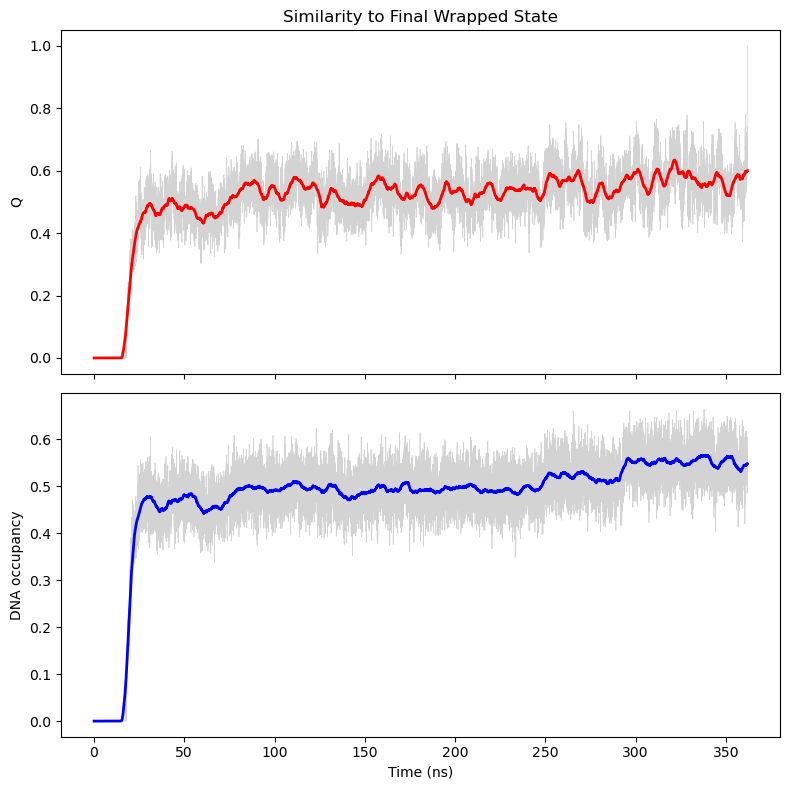

In [37]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis.distances import distance_array
from scipy.ndimage import uniform_filter1d

# --------------------------------------------------
# INPUT
# --------------------------------------------------

topology = "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_initial.pdb"

trajs = [
"/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run2/dna_traj.dcd",
"/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_2/run2/dna_traj.dcd",
]

cutoff_nm = 1.0
cutoff_A = cutoff_nm * 10.0

smooth_window = 500

# --------------------------------------------------
# LOAD
# --------------------------------------------------

u = mda.Universe(topology, trajs)

histone = u.select_atoms(
    "(segid A B C D E F G H) and name BB"
)

dna = u.select_atoms(
    "(segid I J) and (name P S B)"
)

print("Histone beads:", len(histone))
print("DNA beads:", len(dna))

# --------------------------------------------------
# REFERENCE = LAST FRAME
# --------------------------------------------------

u.trajectory[-1]

ref_dist = distance_array(
    dna.positions,
    histone.positions,
    box=u.dimensions
)

ref_min_dist = ref_dist.min(axis=1)

ref_bound = ref_min_dist < cutoff_A

N_ref_bound = np.sum(ref_bound)

print("DNA beads bound in final frame =", N_ref_bound)

# --------------------------------------------------
# ANALYSIS
# --------------------------------------------------

Q = []
occupancy = []
times = []

time_offset = 0.0
prev_time = None

for ts in u.trajectory:

    current_time = ts.time

    # automatic handling of time resets
    if prev_time is not None and current_time < prev_time:

        jump = prev_time

        time_offset += jump

        print(
            f"Time reset detected "
            f"(frame {ts.frame}); "
            f"adding offset {jump:.1f} ps"
        )

    corrected_time = current_time + time_offset

    times.append(corrected_time)

    dist = distance_array(
        dna.positions,
        histone.positions,
        box=u.dimensions
    )

    min_dist = dist.min(axis=1)

    current_bound = min_dist < cutoff_A

    occupancy.append(
        current_bound.sum()/len(dna)
    )

    overlap = np.logical_and(
        ref_bound,
        current_bound
    ).sum()

    Q.append(
        overlap/N_ref_bound
    )

    prev_time = current_time

times = np.array(times)
Q = np.array(Q)
occupancy = np.array(occupancy)

# --------------------------------------------------
# SMOOTH
# --------------------------------------------------

Q_smooth = uniform_filter1d(
    Q,
    size=smooth_window
)

occ_smooth = uniform_filter1d(
    occupancy,
    size=smooth_window
)

# --------------------------------------------------
# SAVE
# --------------------------------------------------

np.savetxt(
    "dna_wrapping.dat",
    np.column_stack(
        (
            times,
            Q,
            occupancy
        )
    ),
    header="time_ps Q_final_state occupancy"
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig, ax = plt.subplots(
    2,
    1,
    figsize=(8,8),
    sharex=True
)

ax[0].plot(
    times/1000,
    Q,
    color="lightgrey",
    linewidth=0.5
)

ax[0].plot(
    times/1000,
    Q_smooth,
    color="red",
    linewidth=2
)

ax[0].set_ylabel("Q")
ax[0].set_title(
    "Similarity to Final Wrapped State"
)

ax[1].plot(
    times/1000,
    occupancy,
    color="lightgrey",
    linewidth=0.5
)

ax[1].plot(
    times/1000,
    occ_smooth,
    color="blue",
    linewidth=2
)

ax[1].set_ylabel(
    "DNA occupancy"
)

ax[1].set_xlabel(
    "Time (ns)"
)

plt.tight_layout()
# plt.savefig(
#     "dna_wrapping.png",
#     dpi=300
# )

plt.show()

Histone beads: 952
DNA beads: 874
DNA beads bound in final frame = 455
Time reset detected (frame 4676); adding offset 46760.0 ps


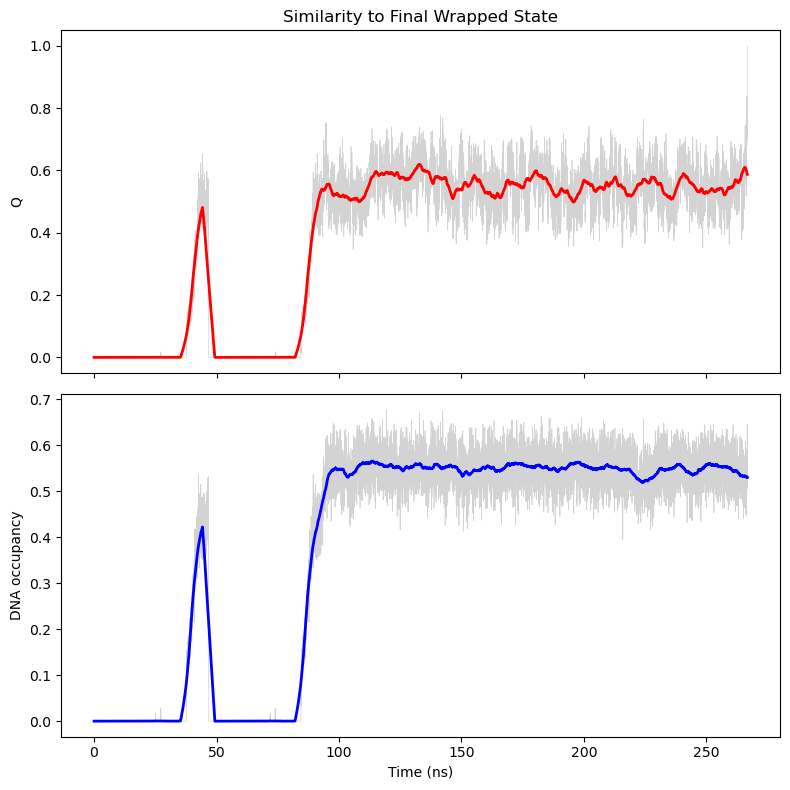

In [38]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis.distances import distance_array
from scipy.ndimage import uniform_filter1d

# --------------------------------------------------
# INPUT
# --------------------------------------------------

topology = "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_initial.pdb"

trajs = [
"/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_3/run1/dna_traj.dcd",
"/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_3/run1/dna_traj.dcd",
]

cutoff_nm = 1.0
cutoff_A = cutoff_nm * 10.0

smooth_window = 500

# --------------------------------------------------
# LOAD
# --------------------------------------------------

u = mda.Universe(topology, trajs)

histone = u.select_atoms(
    "(segid A B C D E F G H) and name BB"
)

dna = u.select_atoms(
    "(segid I J) and (name P S B)"
)

print("Histone beads:", len(histone))
print("DNA beads:", len(dna))

# --------------------------------------------------
# REFERENCE = LAST FRAME
# --------------------------------------------------

u.trajectory[-1]

ref_dist = distance_array(
    dna.positions,
    histone.positions,
    box=u.dimensions
)

ref_min_dist = ref_dist.min(axis=1)

ref_bound = ref_min_dist < cutoff_A

N_ref_bound = np.sum(ref_bound)

print("DNA beads bound in final frame =", N_ref_bound)

# --------------------------------------------------
# ANALYSIS
# --------------------------------------------------

Q = []
occupancy = []
times = []

time_offset = 0.0
prev_time = None

for ts in u.trajectory:

    current_time = ts.time

    # automatic handling of time resets
    if prev_time is not None and current_time < prev_time:

        jump = prev_time

        time_offset += jump

        print(
            f"Time reset detected "
            f"(frame {ts.frame}); "
            f"adding offset {jump:.1f} ps"
        )

    corrected_time = current_time + time_offset

    times.append(corrected_time)

    dist = distance_array(
        dna.positions,
        histone.positions,
        box=u.dimensions
    )

    min_dist = dist.min(axis=1)

    current_bound = min_dist < cutoff_A

    occupancy.append(
        current_bound.sum()/len(dna)
    )

    overlap = np.logical_and(
        ref_bound,
        current_bound
    ).sum()

    Q.append(
        overlap/N_ref_bound
    )

    prev_time = current_time

times = np.array(times)
Q = np.array(Q)
occupancy = np.array(occupancy)

# --------------------------------------------------
# SMOOTH
# --------------------------------------------------

Q_smooth = uniform_filter1d(
    Q,
    size=smooth_window
)

occ_smooth = uniform_filter1d(
    occupancy,
    size=smooth_window
)

# --------------------------------------------------
# SAVE
# --------------------------------------------------

np.savetxt(
    "dna_wrapping.dat",
    np.column_stack(
        (
            times,
            Q,
            occupancy
        )
    ),
    header="time_ps Q_final_state occupancy"
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig, ax = plt.subplots(
    2,
    1,
    figsize=(8,8),
    sharex=True
)

ax[0].plot(
    times/1000,
    Q,
    color="lightgrey",
    linewidth=0.5
)

ax[0].plot(
    times/1000,
    Q_smooth,
    color="red",
    linewidth=2
)

ax[0].set_ylabel("Q")
ax[0].set_title(
    "Similarity to Final Wrapped State"
)

ax[1].plot(
    times/1000,
    occupancy,
    color="lightgrey",
    linewidth=0.5
)

ax[1].plot(
    times/1000,
    occ_smooth,
    color="blue",
    linewidth=2
)

ax[1].set_ylabel(
    "DNA occupancy"
)

ax[1].set_xlabel(
    "Time (ns)"
)

plt.tight_layout()
# plt.savefig(
#     "dna_wrapping.png",
#     dpi=300
# )

plt.show()

Histone beads: 952
DNA beads: 874
DNA beads bound in final frame = 438
Time reset detected (frame 4685); adding offset 46850.0 ps


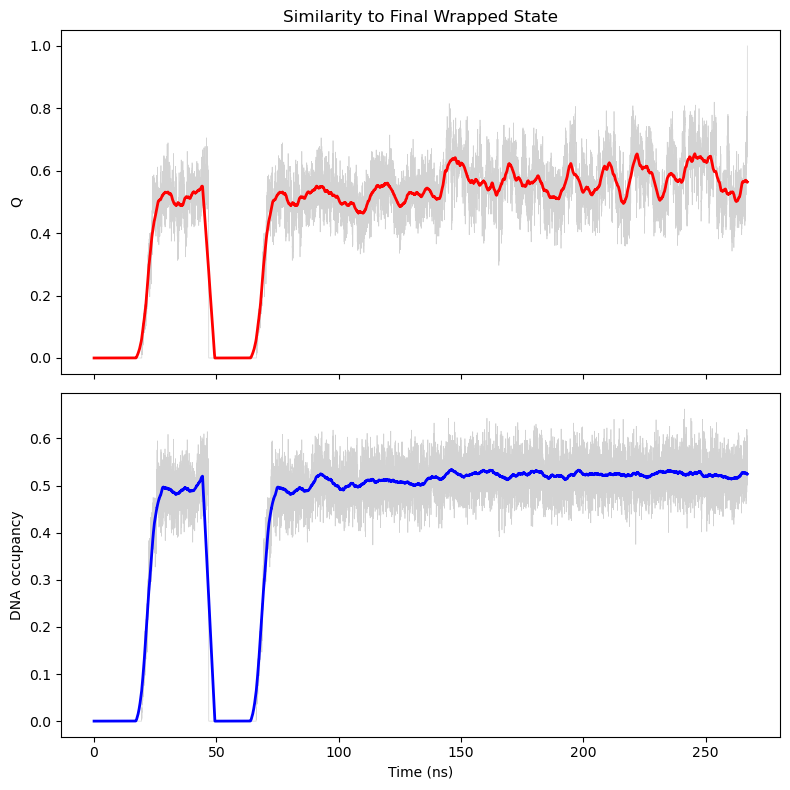

In [39]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis.distances import distance_array
from scipy.ndimage import uniform_filter1d

# --------------------------------------------------
# INPUT
# --------------------------------------------------

topology = "/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_2/run1/dna_initial.pdb"

trajs = [
"/data/cg_dna_histone/KIRTI/submission_1/nucleosome_sim_3/run2/dna_traj.dcd",
"/data/cg_dna_histone/KIRTI/submission_2/nucleosome_sim_3/run2/dna_traj.dcd",
]

cutoff_nm = 1.0
cutoff_A = cutoff_nm * 10.0

smooth_window = 500

# --------------------------------------------------
# LOAD
# --------------------------------------------------

u = mda.Universe(topology, trajs)

histone = u.select_atoms(
    "(segid A B C D E F G H) and name BB"
)

dna = u.select_atoms(
    "(segid I J) and (name P S B)"
)

print("Histone beads:", len(histone))
print("DNA beads:", len(dna))

# --------------------------------------------------
# REFERENCE = LAST FRAME
# --------------------------------------------------

u.trajectory[-1]

ref_dist = distance_array(
    dna.positions,
    histone.positions,
    box=u.dimensions
)

ref_min_dist = ref_dist.min(axis=1)

ref_bound = ref_min_dist < cutoff_A

N_ref_bound = np.sum(ref_bound)

print("DNA beads bound in final frame =", N_ref_bound)

# --------------------------------------------------
# ANALYSIS
# --------------------------------------------------

Q = []
occupancy = []
times = []

time_offset = 0.0
prev_time = None

for ts in u.trajectory:

    current_time = ts.time

    # automatic handling of time resets
    if prev_time is not None and current_time < prev_time:

        jump = prev_time

        time_offset += jump

        print(
            f"Time reset detected "
            f"(frame {ts.frame}); "
            f"adding offset {jump:.1f} ps"
        )

    corrected_time = current_time + time_offset

    times.append(corrected_time)

    dist = distance_array(
        dna.positions,
        histone.positions,
        box=u.dimensions
    )

    min_dist = dist.min(axis=1)

    current_bound = min_dist < cutoff_A

    occupancy.append(
        current_bound.sum()/len(dna)
    )

    overlap = np.logical_and(
        ref_bound,
        current_bound
    ).sum()

    Q.append(
        overlap/N_ref_bound
    )

    prev_time = current_time

times = np.array(times)
Q = np.array(Q)
occupancy = np.array(occupancy)

# --------------------------------------------------
# SMOOTH
# --------------------------------------------------

Q_smooth = uniform_filter1d(
    Q,
    size=smooth_window
)

occ_smooth = uniform_filter1d(
    occupancy,
    size=smooth_window
)

# --------------------------------------------------
# SAVE
# --------------------------------------------------

np.savetxt(
    "dna_wrapping.dat",
    np.column_stack(
        (
            times,
            Q,
            occupancy
        )
    ),
    header="time_ps Q_final_state occupancy"
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig, ax = plt.subplots(
    2,
    1,
    figsize=(8,8),
    sharex=True
)

ax[0].plot(
    times/1000,
    Q,
    color="lightgrey",
    linewidth=0.5
)

ax[0].plot(
    times/1000,
    Q_smooth,
    color="red",
    linewidth=2
)

ax[0].set_ylabel("Q")
ax[0].set_title(
    "Similarity to Final Wrapped State"
)

ax[1].plot(
    times/1000,
    occupancy,
    color="lightgrey",
    linewidth=0.5
)

ax[1].plot(
    times/1000,
    occ_smooth,
    color="blue",
    linewidth=2
)

ax[1].set_ylabel(
    "DNA occupancy"
)

ax[1].set_xlabel(
    "Time (ns)"
)

plt.tight_layout()
# plt.savefig(
#     "dna_wrapping.png",
#     dpi=300
# )

plt.show()